# EDIBLES Manual Analysis: The Notebook Version


## Step 0: Imports

Pull in numpy and matplotlib for the obvious reasons, plus the two EDIBLES helpers that find files and load spectra. Then the four local files that live in this same folder: the loader, the co adder, the fit driver, and the Voigt model itself.

If any of these imports fail, your conda env probably isn't active. Quit Jupyter, run `conda activate edilbles_dr5`, then relaunch.

In [13]:
# The usual suspects
import numpy as np
import matplotlib.pyplot as plt

# The EDIBLES bits that find files and load spectra
from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum

# Our project's own helpers (these live in the same folder as this notebook)
from flux_wave_find import wave_flux_data
from co_adding_flux import coadd_spectra
from main_run import get_species_data, astrovoigtfit_run
from main import master_function
from edibles.projects.edr5_integration import transformations

# Make the plots a bit less ugly
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All imports happy. Onward.')

All imports happy. Onward.


## Step 1: Pick a star and a transition

Tell the code three things:

* `star_name`: an EDIBLES sightline (something like `HD 183143`, `HD 147889`, etc.)
* `target_wave`: the rest wavelength of the line you care about, in angstroms. For example, the 12CH+ line near 4232.5 A, or the Li doublet around 6707.8 A.
* `wrange`: a wavelength window around that line. Make it a bit wider than the absorption itself so you have continuum on either side to anchor the fit later.

If you don't know what species you want, peek inside `species.txt` (in this folder). It lists everything the code already knows about, including the recommended wavelength range for each. The next cell prints it for you, no need to open the file.

In [14]:
star_name = 'HD 147889'
target_wave = 7698.965          # rest wavelength of the 12CH+_4032 line
wrange = [7697.0, 7700.0]       # window around the line for loading data

# Show every species the code already knows about
all_species = get_species_data('species.txt')
print('Species I know about:')
for name, info in all_species.items():
    print(f"  {name:20s} line={info['line']}  wrange={info['wrange']}")

Species I know about:
  K_4044               line=4044.142  wrange=[4043.0, 4045.0]
  K_7699               line=7698.965  wrange=[7697.0, 7700.0]
  12CH+_4032           line=4232.548  wrange=[4231.5, 4233.5]
  13CH+_4032           line=4232.548  wrange=[4231.5, 4233.5]
  7Li_6707             line=6707.761  wrange=[6707.1, 6708.2]
  6Li_6707             line=6707.761  wrange=[6707.1, 6708.2]
  Na_D_5892            line=5889.951  wrange=[5889.0, 5897.0]
  85Rb_7800            line=7800.250  wrange=[7798.0, 7800.9]
  87Rb_7800            line=7800.250  wrange=[7798.0, 7800.9]


## Step 2: Ask EDIBLES which observations exist

EdiblesOracle is the catalog wizard. We point it at our star and our wavelength, and it hands back the list of FITS files that actually cover that wavelength region. Nothing gets loaded yet, this is just window shopping.

In [15]:
oracle = EdiblesOracle()
files = oracle.getFilteredObsList([star_name], Wave=target_wave, MergedOnly=False)

# Turn it into a plain list so we can index it like normal humans
if hasattr(files, 'tolist'):
    files = files.tolist()

print(f'Found {len(files)} files covering {target_wave} A for {star_name}:\n')
for i, f in enumerate(files):
    print(f'  [{i}]  {f}')

***Common Objects***
['HD 147889']
**Filtered File List**
6674    orders/HD147889_2016-08-07T02:17:25_860nm_redl...
6905    combined/HD147889_2016-08-07T01:53:07_860nm_re...
6941    orders/HD147889_2016-08-07T01:10:05_860nm_redl...
7004    combined/HD147889_2016-08-07T01:10:05_860nm_re...
7018    orders/HD147889_2016-08-07T01:53:07_860nm_redl...
7032    orders/HD147889_2016-07-28T03:03:59_860nm_redl...
7051    combined/HD147889_2016-08-07T02:17:25_860nm_re...
7128    combined/HD147889_2016-07-28T03:03:59_860nm_re...
Name: Filename, dtype: str
8
Found 8 files covering 7698.965 A for HD 147889:

  [0]  orders/HD147889_2016-08-07T02:17:25_860nm_redl_O13.fits
  [1]  combined/HD147889_2016-08-07T01:53:07_860nm_redl.fits
  [2]  orders/HD147889_2016-08-07T01:10:05_860nm_redl_O13.fits
  [3]  combined/HD147889_2016-08-07T01:10:05_860nm_redl.fits
  [4]  orders/HD147889_2016-08-07T01:53:07_860nm_redl_O13.fits
  [5]  orders/HD147889_2016-07-28T03:03:59_860nm_redl_O13.fits
  [6]  combined/HD147889_

## Step 3: Pick which files to co add

You probably don't want all of them. Some observations are noisy, some are taken at weird epochs, some are basically duplicates of each other. Look at the list above and pick the indices you want. If you trust them all, just use `list(range(len(files)))`.

We'll also overplot the individual spectra in this cell so you can spot any obvious weirdos before mixing them together.

Loaded file 0: 88 points
Loaded file 2: 88 points
Loaded file 5: 88 points


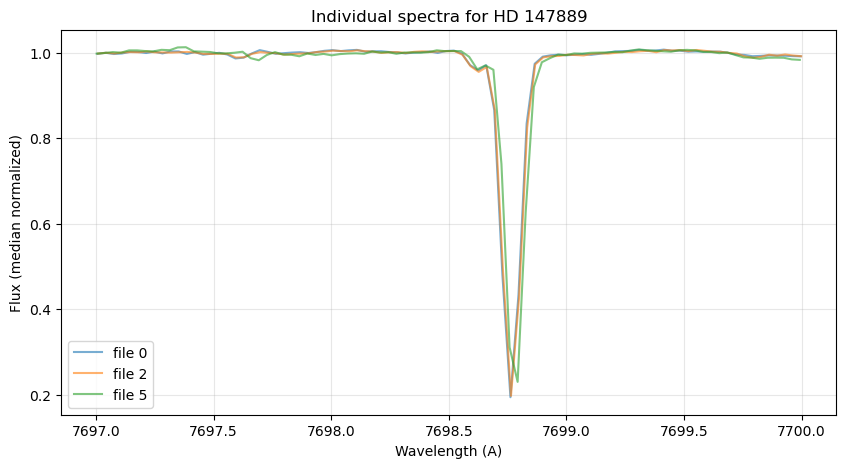

In [16]:
# Pick the indices of the files you want to co add (edit this list)
selected_indices = [0,2,5]

# Pull each spectrum from disk (just the wavelength window, median normalized)
wave_list = []
flux_list = []

for i in selected_indices:
    fname = files[i]
    w, f = wave_flux_data(star_name=star_name, wave=target_wave,
                          wrange=wrange, file_name=fname)
    if w is None or len(w) == 0:
        print(f'Skipping file {i}: no data in range')
        continue
    wave_list.append(w)
    flux_list.append(f)
    print(f'Loaded file {i}: {len(w)} points')

# Quick look so you can spot weirdos
plt.figure()
for i, (w, f) in enumerate(zip(wave_list, flux_list)):
    plt.plot(w, f, alpha=0.6, label=f'file {selected_indices[i]}')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux (median normalized)')
plt.title(f'Individual spectra for {star_name}')
plt.legend()
plt.show()

## Step 4: Co add the chosen spectra

Now we squash them into one cleaner spectrum. The `coadd_spectra` function interpolates everything onto a common wavelength grid (it uses the first spectrum by default) and then does a weighted average using your per spectrum sigma.

* If you give it one sigma value, it gets used for all spectra.
* If you give it a list of sigmas, the list has to match the number of spectra one to one.
* If you give it nothing, it just averages and estimates the noise from the scatter.

Co added spectrum: 88 points
Estimated noise of the co added flux: 0.0011547005383792516


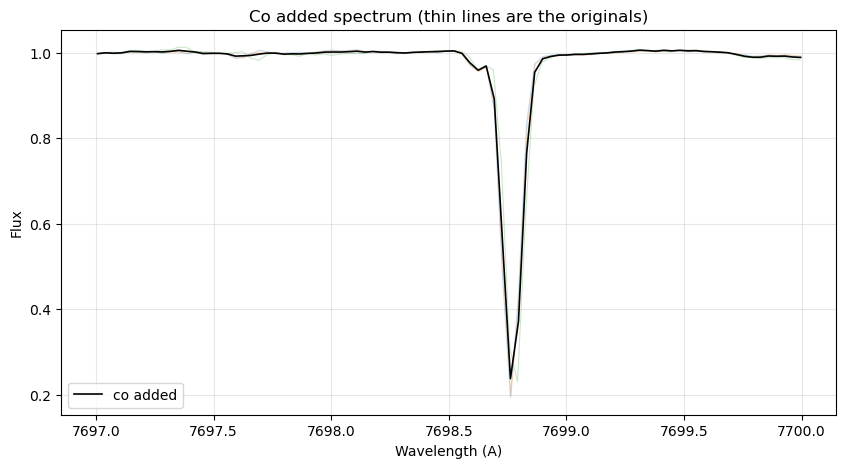

In [17]:
sigma_per_spectrum = 0.002   # noise estimate per individual spectrum

wave_coadd, flux_coadd, sigma_coadd = coadd_spectra(
    wave_list, flux_list, sigma_list=sigma_per_spectrum,
)

print(f'Co added spectrum: {len(wave_coadd)} points')
print(f'Estimated noise of the co added flux: {sigma_coadd}')

plt.figure()
for w, f in zip(wave_list, flux_list):
    plt.plot(w, f, alpha=0.25, lw=0.8)
plt.plot(wave_coadd, flux_coadd, color='black', lw=1.2, label='co added')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title('Co added spectrum (thin lines are the originals)')
plt.legend()
plt.show()

## Step 5: Pick the fit range and the absorption range

Two windows, both important. Don't confuse them.

* **fit_range** is the bigger window. This is what we actually fit (continuum + line, together). It should include plenty of unblocked continuum on either side of the line so the spline has somewhere to rest.
* **absorption_range** is the smaller window where the absorption feature actually lives. The code uses this to tell the spline knots, very politely, to stay out of here. Make it just wide enough to cover the feature.

The next cell shades both ranges on top of your co added spectrum so you can eyeball whether you got them right.

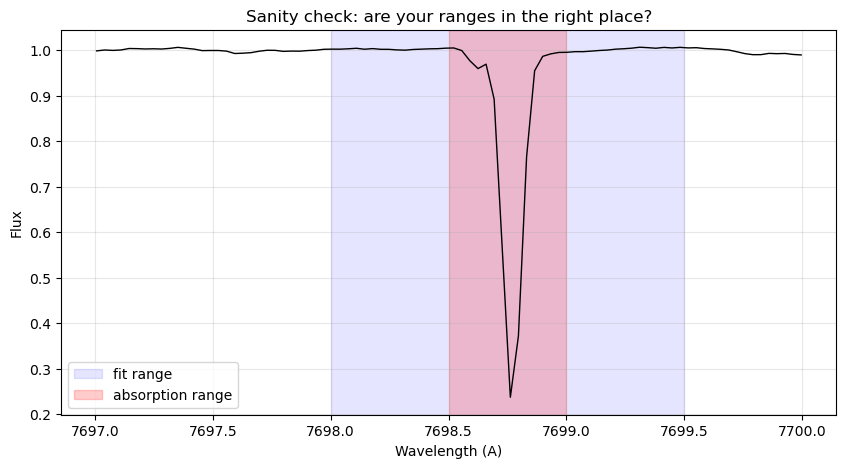

After cropping to fit range: 44 points


In [18]:
fit_range = (7698, 7699.5)
absorption_range = (7698.5, 7699)

plt.figure()
plt.plot(wave_coadd, flux_coadd, color='black', lw=1)
plt.axvspan(*fit_range, color='blue', alpha=0.1, label='fit range')
plt.axvspan(*absorption_range, color='red', alpha=0.2, label='absorption range')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title('Sanity check: are your ranges in the right place?')
plt.legend()
plt.show()

# Crop the data to the fit range so we hand only the relevant chunk to the fitter
mask = (wave_coadd >= fit_range[0]) & (wave_coadd <= fit_range[1])
wave_fit = wave_coadd[mask]
flux_fit = flux_coadd[mask]
print(f'After cropping to fit range: {len(wave_fit)} points')

## Step 6: Set up the species and their initial guesses

For each species you want to fit, you need:

* **name**: the species key from `species.txt`. This is how the code looks up rest wavelength, oscillator strength, and gamma. Spell it exactly the way it appears in the file.
* **b**: Doppler broadening in km/s, one value per velocity component. So two numbers means two components.
* **N**: column density in atoms per cm^2, also one per component.
* **v_rad**: radial velocity in km/s, one per component.

The b, N, and v_rad lists for a given species must all have the same length (one entry per component). If you only have one velocity component, just pass single element lists like `[2.0]`.

If you're fitting multiple species and want some of them to share the same b and v_rad (very common when isotopes ride along together), set `'tie_b': True` and `'tie_v_rad': True` on the species that should follow species 0. Species 0 is always the boss, the others can choose to copy it.

In [31]:
molecules = ['K_7699'] #this should match with the first column of species.txt

species_params = {
    0: {
        'b':     [1.5,1.5],
        'N':     [1e11,1e13],
        'v_rad': [-13,-7],
    } #,   # uncomment if you have  second species
    # 1: {
    #     'b':     [2.0, 2.0],
    #     'N':     [1e12, 1e12],
    #     'v_rad': [5,5],
    # }
}

 

print(f"You're fitting {len(molecules)} species with these components:")
for i, mol in enumerate(molecules):
    p = species_params[i]
    print(f"  {mol}: {len(p['b'])} component(s)")
    print(f"    b     = {p['b']}")
    print(f"    N     = {p['N']}")
    print(f"    v_rad = {p['v_rad']}")

You're fitting 1 species with these components:
  K_7699: 2 component(s)
    b     = [1.5, 1.5]
    N     = [100000000000.0, 10000000000000.0]
    v_rad = [-13, -7]


## Step 7: Place the continuum anchor points (the spline knots)

The continuum is a spline, and you control where its knots go. Two flavors here, pick whichever vibes with you.

**Flavor A (auto, equidistant):** You tell the code how many knots you want with `n_knots`, and it spreads them evenly across the fit range, automatically skipping any that would land inside the absorption range and adding anchor knots just outside it. This is what most people use. Leave `knots_x_array = None`.

**Flavor B (manual):** You hand the code an explicit list of wavelengths where the knots should sit. Use this when the auto placement is doing something weird, or when you have weak telluric features you want to anchor around. Set `knots_x_array` to a list of wavelengths and `n_knots` gets ignored.

There's also `spline_order`: 1 is linear, 2 is quadratic, 3 is cubic. Cubic is the default and almost always fine.

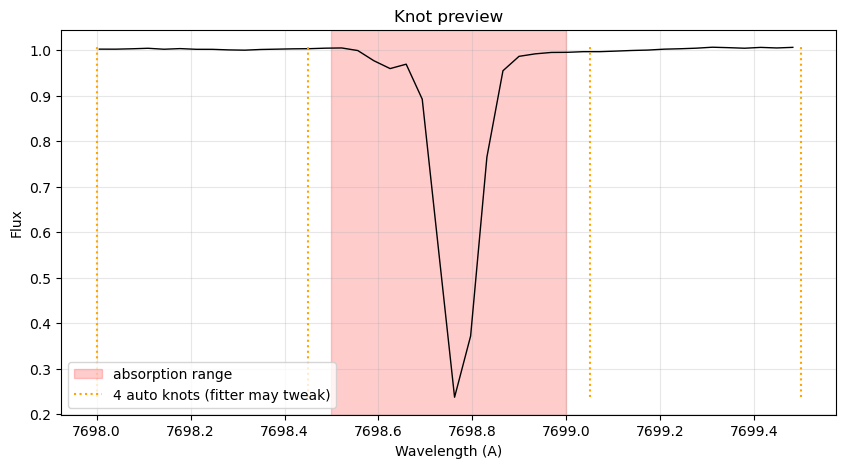

In [32]:
# Flavor A: auto, equidistant knots, just say how many
n_knots = 2
knots_x_array = None

# Flavor B: manual, you say exactly where every knot goes
# Uncomment the next line to use manual mode (it overrides n_knots)
# knots_x_array = [4231.6, 4231.8, 4232.0, 4232.9, 4233.1, 4233.3, 4233.45]

spline_order = 3   # 1 linear, 2 quadratic, 3 cubic

# Preview where the knots would land
if knots_x_array is None:
    preview_knots = np.linspace(fit_range[0], fit_range[1], n_knots)
    inside_abs = (preview_knots >= absorption_range[0]) & (preview_knots <= absorption_range[1])
    preview_knots = preview_knots[~inside_abs]
    preview_knots = np.sort(np.unique(np.append(
        preview_knots, [absorption_range[0] - 0.05, absorption_range[1] + 0.05])))
    knot_label = f'{len(preview_knots)} auto knots (fitter may tweak)'
else:
    preview_knots = np.asarray(knots_x_array)
    knot_label = f'{len(preview_knots)} manual knots'

plt.figure()
plt.plot(wave_fit, flux_fit, color='black', lw=1)
plt.axvspan(*absorption_range, color='red', alpha=0.2, label='absorption range')
plt.vlines(preview_knots, flux_fit.min(), flux_fit.max(),
           colors='orange', linestyles=':', label=knot_label)
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title('Knot preview')
plt.legend()
plt.show()

## Step 8: Run the joint continuum + Voigt fit

This is the moment of truth. `astrovoigtfit_run` fits the spline continuum and the Voigt absorption together in one optimization, not sequentially. That's the right way to do it because the continuum and the line wings care about each other, and fitting them in series throws away that coupling.

It returns:

* `fitresult`: the full lmfit ModelResult (everything you need lives in here)
* `normalized_flux`: the data divided by the fitted continuum
* `continuum`: the fitted continuum on its own
* `residual_std`: standard deviation of (flux minus best fit), just for diagnostics. Don't confuse it with `fit_std_dev`, which is the input noise.

`fit_std_dev` is the noise of the co added spectrum and gets used as `1/sigma` weights inside lmfit. If your co added spectrum is noisier than 0.002, crank this up so the fit doesn't try too hard to chase every wiggle.

In [33]:
fit_std_dev = 0.004 # standard dev of the co-added spectra 
# this is a very important parameter... ideally you should find 
# this by taking a wavelength region from the spectra where the continuum
# is pretty flatt with almost no absorption and fitting it 
# with a line and find the stardard dev of the data points 

fitresult, normalized_flux, continuum, residual_std = astrovoigtfit_run(
    wave_fit, flux_fit, molecules, species_params,
    absorption_range, n_knots=n_knots, knots_x_array=knots_x_array,
    species_file='species.txt', spline_order=spline_order,
    std_dev=fit_std_dev,
)

print(f'\nFit success:        {fitresult.success}')
print(f'Chi square:         {fitresult.chisqr:.4f}')
print(f'Reduced chi square: {fitresult.redchi:.4f}')
print(f'Std of residuals:   {residual_std:.5f}')

Species: K_7699, Lambda: [7698.965], f: [0.3331], Gamma: [37400000.0]
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([1.5, 1.5]), 'N_1st': array([1.e+11, 1.e+13]), 'v_rad_1st': array([-13.,  -7.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([1.5, 1.5]), 'N_1st': array([1.e+11, 1.e+13]), 'v_rad_1st': array([-13.,  -7.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([1.5, 1.5]), 'N_1st': array([1.e+11, 1.e+13]), 'v_rad_1st': array([-13.,  -7.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([1.5, 1.5]), 'N_1st': array([1.e+11, 1.e+13]), 'v_rad_1st': array([-13.,  -7.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': ar

## Step 9: Look at the answers

Pull the best fit numbers out of the fit result for each species and component. The errors come from lmfit's covariance estimate, which is fine most of the time but can be optimistic if the fit is degenerate (think very blended components or weak lines).

We also plot:

* the data with the fitted continuum and the total fit on top
* the normalized flux (data / continuum) with the absorption model on top
* the residuals (should look like noise centered on zero)

In [34]:
params = fitresult.params

print(f'Star: {star_name}')
print('=' * 40)
for i, mol in enumerate(molecules):
    print(f'\nSpecies {i+1}: {mol}')
    comp_idx = 0
    while f'b_{i}_{comp_idx}' in params:
        b = params[f'b_{i}_{comp_idx}']
        N = params[f'N_{i}_{comp_idx}']
        v = params[f'v_rad_{i}_{comp_idx}']
        print(f'  Component {comp_idx+1}:')
        for p, label in [(b, 'b    '), (N, 'N    '), (v, 'v_rad')]:
            if p.stderr is None:
                print(f'    {label}: {p.value:.4g}  (fixed or tied)')
            else:
                pct = abs(p.stderr / p.value) * 100 if p.value != 0 else 0
                print(f'    {label}: {p.value:.4g} +/- {p.stderr:.4g}  ({pct:.2f}%)')
        comp_idx += 1

print(f'\nChi square:         {fitresult.chisqr:.4f}')
print(f'Reduced chi square: {fitresult.redchi:.4f}')

Star: HD 147889

Species 1: K_7699
  Component 1:
    b    : 4.259 +/- 5.696  (133.76%)
    N    : 7.777e+09 +/- 7.638e+09  (98.21%)
    v_rad: -13.02 +/- 1.857  (14.26%)
  Component 2:
    b    : 0.749 +/- 0.01088  (1.45%)
    N    : 6.303e+12 +/- 1.17e+12  (18.57%)
    v_rad: -3.795 +/- 0.01112  (0.29%)

Chi square:         277.2242
Reduced chi square: 7.2954


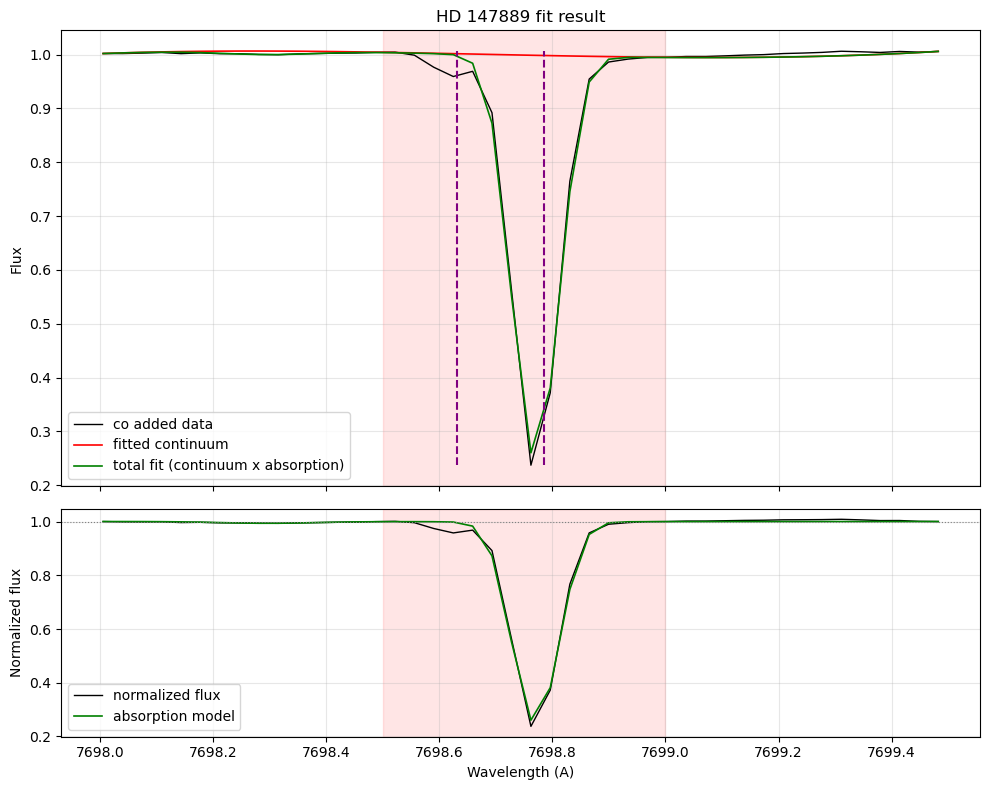

In [35]:
# Top: data + continuum + total fit. Bottom: normalized flux + absorption model.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

wave_list = transformations.rv_to_wavelength(np.array(species_params[0]['v_rad']), target_wave)
ax_top = axes[0]
ax_top.plot(wave_fit, flux_fit, color='black', lw=1, label='co added data')
ax_top.plot(wave_fit, continuum, color='red', lw=1.2, label='fitted continuum')
ax_top.plot(wave_fit, fitresult.best_fit, color='green', lw=1.2,
            label='total fit (continuum x absorption)')
ax_top.axvspan(*absorption_range, color='red', alpha=0.1)
ax_top.set_ylabel('Flux')
ax_top.set_title(f'{star_name} fit result')
ax_top.legend()
ax_top.vlines(wave_list, flux_fit.min(), flux_fit.max(), colors='purple', linestyles='--', label='v_rad positions')

ax_bot = axes[1]
ax_bot.plot(wave_fit, normalized_flux, color='black', lw=1, label='normalized flux')
ax_bot.plot(wave_fit, fitresult.best_fit / continuum, color='green', lw=1.2,
            label='absorption model')
ax_bot.axhline(1.0, color='gray', lw=0.8, linestyle=':')
ax_bot.axvspan(*absorption_range, color='red', alpha=0.1)
ax_bot.set_xlabel('Wavelength (A)')
ax_bot.set_ylabel('Normalized flux')
ax_bot.legend()

plt.tight_layout()
plt.show()

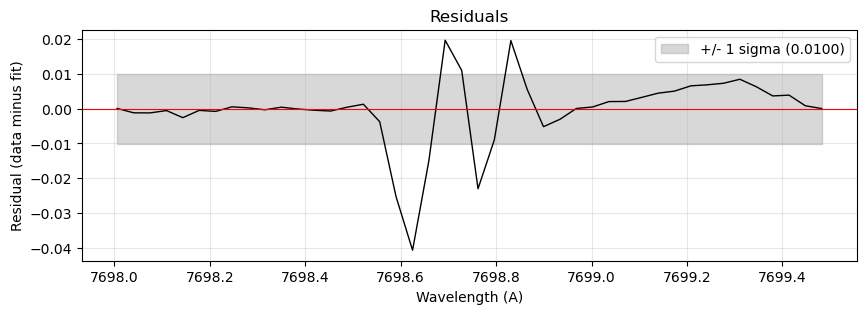

In [36]:
# Residuals: data minus total fit. Should look like noise centered on zero.
plt.figure(figsize=(10, 3))
plt.plot(wave_fit, flux_fit - fitresult.best_fit, color='black', lw=1)
plt.axhline(0, color='red', lw=0.8)
plt.fill_between(wave_fit, -residual_std, residual_std, color='gray', alpha=0.3,
                 label=f'+/- 1 sigma ({residual_std:.4f})')
plt.xlabel('Wavelength (A)')
plt.ylabel('Residual (data minus fit)')
plt.title('Residuals')
plt.legend()
plt.show()

## That's it. You did science.

A few things to try from here when something looks off, or when you want to push further:

* **Bad fit?** Check your initial guesses. Voigt fits are not magic, they need a reasonable starting point for N, b, and v_rad. The most common reason for weird results is a v_rad that's off by enough that the line center starts in the wrong place.

* **Want to tie parameters across species?** Set `'tie_b': True` and `'tie_v_rad': True` on species index 1 (and above) in `species_params`. Useful for isotopes that should share the same kinematics. Re run from Step 6 onward.

* **Continuum looks off?** Try more knots, or switch to manual knot placement (Flavor B in Step 7). You can also drop the spline order to 2 or 1 if cubic is overfitting the wiggles.

* **Adding a new species?** Open `species.txt` and add a row with name, line, lambda list, f list, gamma list, and a default wrange. Then re run from the top.

* **Want to save the fit?** `fitresult.fit_report()` gives you a fat string with everything you'd want to paste into a paper. Stash it in a text file.

Good luck out there, and may your residuals always look like noise.